In [1]:
using DriftDiffusionModels
using DataFrames
using Dates
using CSV
using Plots


SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up


In [2]:
ddir = "../data/mouse_df.csv"
# load in the data
df = CSV.File(ddir) |> DataFrame;

In [3]:
# Group by animal name and count trials
trial_counts = combine(groupby(df, :name), nrow => :trial_count)

# Sort by count in descending order
sort!(trial_counts, :trial_count, rev=true)

# pick a mouse of interest (start with mouse of most trials)
moi = trial_counts[1, :name]

# get the data for the mouse of interest
mouse_df = df[df.name .== moi, :]

# Filter out trials with "omission" outcome
valid_trials = findall(outcome -> outcome != "omission", mouse_df.outcome)
filtered_df = mouse_df[valid_trials, :]

# Map correct -> 1 and incorrect -> -1 (only for error and correct, omissions are gone)
numeric_outcomes = [outcome == "correct" ? 1 : -1 for outcome in filtered_df.outcome]

# Get reaction times, filter out "NAN" values
valid_rt_indices = findall(rt -> uppercase(string(rt)) != "NAN", filtered_df.rt)
# valid_trials = findall(rt -> rt > 0.2, filtered_df.rt)

# Apply both filters to keep data aligned
final_df = filtered_df[valid_rt_indices, :]
final_outcomes = numeric_outcomes[valid_rt_indices]

# Convert RTs to Float64
# final_rts = [parse(Float64, rt) for rt in final_df.rt]
final_rts = final_df.rt
final_stimulus = final_df.correct_side
final_stimulus = [stim == "right" ? 1 : -1 for stim in final_stimulus]

# Extract just the date part from the timestamp strings
dates = [Date(split(dt)[1]) for dt in final_df.trial_datetime]

# Get unique dates in chronological order
unique_dates = sort(unique(dates))

# Create a vector of vectors, where each inner vector contains DDMResults for one day
results_by_date = Vector{Vector{DDMResult}}()

for date in unique_dates
    # Get indices for this date
    day_indices = findall(dates .== date)
    
    # Skip days with no valid data
    if isempty(day_indices)
        continue
    end
    
    # Extract RTs and outcomes for this date
    day_rts = final_rts[day_indices]
    day_outcomes = final_outcomes[day_indices]
    day_stim_side = final_stimulus[day_indices]
    
    # Create DDMResult objects for this day
    day_results = [DDMResult(rt, choice, stim) for (rt, choice, stim) in zip(day_rts, day_outcomes, day_stim_side)]

    # Add to our vector of vectors
    push!(results_by_date, day_results)
end

# Now calculate the sequence ends (cumulative sum of lengths)
seq_ends = cumsum([length(seq) for seq in results_by_date])

# Concatenate all results into a single vector
all_results = reduce(vcat, results_by_date)

12311-element Vector{DDMResult}:
 DDMResult(0.2716, 1, -1)
 DDMResult(0.4124, -1, 1)
 DDMResult(0.2669, 1, -1)
 DDMResult(0.8428, 1, 1)
 DDMResult(0.3541, 1, 1)
 DDMResult(0.247, 1, -1)
 DDMResult(0.4099, 1, -1)
 DDMResult(0.2372, -1, -1)
 DDMResult(0.3275, -1, 1)
 DDMResult(0.2344, 1, 1)
 ⋮
 DDMResult(0.4864, 1, 1)
 DDMResult(0.2847, -1, -1)
 DDMResult(0.2424, 1, 1)
 DDMResult(0.4899, -1, -1)
 DDMResult(0.226, -1, -1)
 DDMResult(0.2562, -1, -1)
 DDMResult(0.5747, 1, -1)
 DDMResult(0.3208, 1, 1)
 DDMResult(0.4196, 1, -1)

In [4]:
hyper, qs, elbo_history = fit_vi_gaussian(all_results; n_iter=25, K=25, verbose=true)

Data-driven init: B=0.778, τ=0.234, v=0.655
VI iter 1
  ELBO: -32822.79320060856
VI iter 2
  ELBO: -18219.041717242177
VI iter 3
  ELBO: -14075.937874475529
VI iter 4
  ELBO: -11196.584447951916
VI iter 5
  ELBO: -9511.97364658002
VI iter 6
  ELBO: -8169.981956831752
VI iter 7
  ELBO: -7034.263901359699
VI iter 8
  ELBO: -6451.326693658472
VI iter 9
  ELBO: -5826.768022079775
VI iter 10
  ELBO: -5506.528193353966
VI iter 11
  ELBO: -5105.256352827251
VI iter 12
  ELBO: -4513.120207562437
VI iter 13
  ELBO: -4305.913011506603
VI iter 14
  ELBO: -4256.869442398455
VI iter 15
  ELBO: -3928.757706730059
VI iter 16
  ELBO: -3916.005794468869
VI iter 17
  ELBO: -3739.6038812879533
VI iter 18
  ELBO: -3632.3792269516607
VI iter 19
  ELBO: -3490.663223269911
VI iter 20
  ELBO: -3319.0920713130754
VI iter 21
  ELBO: -3320.9430377341705
VI iter 22
  ELBO: -3198.1825760421416
VI iter 23
  ELBO: -3018.1270964959617
VI iter 24
  ELBO: -3007.320910530595
VI iter 25
  ELBO: -2965.3322276808317


(DriftDiffusionModels.DDMHyper{Float64}([-0.15316169809033098, -1.6111437970797986, -0.6174658214833731, 0.1759838620313426], [-1.2718382679822045, -2.2250938997452, -0.2893455778335316, -1.2569184554794306]), DriftDiffusionModels.TrialVIParams{Float64}[DriftDiffusionModels.TrialVIParams{Float64}([-0.27402055375532136, -1.5998800297084916, -0.7657846212243986, 0.24882310941825994], [-1.554934825174893, -2.2472590975723485, -0.3873494414452705, -1.3050736995684278]), DriftDiffusionModels.TrialVIParams{Float64}([-0.10295304982548063, -1.5935630038191075, -0.8102761312468044, 0.15035219598904087], [-1.521920177303799, -2.239149239483392, -0.39055695730262385, -1.2461717756228414]), DriftDiffusionModels.TrialVIParams{Float64}([-0.22699025898570432, -1.593622322026973, -0.731554360915604, 0.22836200717837835], [-1.3573286129861017, -2.304014185978008, -0.3562646691096095, -1.226470525174949]), DriftDiffusionModels.TrialVIParams{Float64}([0.15527549643536662, -1.5987782326436726, -0.63917866

In [5]:
B = [exp(i.μ[1]) for i in qs]          # boundary separation
τ = [exp(i.μ[2]) for i in qs]          # non-decision time
v = [exp(i.μ[3]) for i in qs]          # drift rate
a0 = [1 / (1 + exp(-i.μ[4])) for i in qs]  # starting point

12311-element Vector{Float64}:
 0.5618868068370722
 0.5375173997616773
 0.5568436868055501
 0.5385578232772682
 0.5418743023513375
 0.565042782494221
 0.5460821393136392
 0.5224437349530492
 0.532398780905494
 0.5678801653013048
 ⋮
 0.5387817560241135
 0.5312503418221034
 0.5658729661031012
 0.5444240622291151
 0.51587030922879
 0.5252556036753789
 0.5446238453688108
 0.5467750789478254
 0.5462196843178376

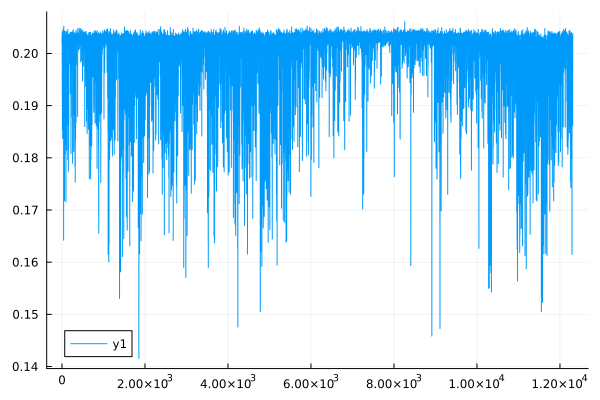

In [6]:
plot(τ)

In [7]:
DriftDiffusionModels.transform_params(hyper.m)

(0.8579909750919628, 0.5393094136475638, 0.5438827686428005, 0.19965911390970012)

In [8]:
using StatsBase
pacf(a0, 1:20)

20-element Vector{Float64}:
 -0.01342357397726256
  0.010547965838550163
  0.0006422882348034845
  0.0045876820911973665
 -0.0031410100785283406
  0.005600562914420289
 -0.01959841347333462
 -0.0058506985366254816
  0.017294913445382292
 -0.0008949291567183692
  0.0012408350513654146
  0.005588510802644505
 -0.006450097017624431
 -0.0014779623422837092
 -0.015877557355592774
  0.024812877075726082
 -0.00860404778274473
  0.014543626827200085
 -0.001149843282609721
  0.015193905391067094